In [1]:
import torch.nn as nn
import matplotlib.pyplot as plt

from black_scholes.pinn.bs_pinn import BlackScholesPINN
from utility.model import EarlyStopping
from config.bs_1d import *
from config.plot_settings import *

In [2]:
seed = 100
print("Training with seed:", seed)
pinn = BlackScholesPINN(model_config, seed=seed)
pinn.set_params(K, r, sigma, T, S_min, S_max)

early_stopping = EarlyStopping(patience=500, min_delta=1e-7)
pinn.train(batch_size=4096, epochs=30000, early_stopping=early_stopping, anneal_freq=50000, alpha=0.9)
pinn.save(f'../../models/bs_pinn_1d/standard/{seed}.pth')

Training with seed: 100
Iter      0 | Train: 1.6887e-01 | Val: 6.7067e-01 | Weights: variational=0.250  terminal=0.250  Smin=0.250  Smax=0.250
Iter    500 | Train: 3.8645e-03 | Val: 1.5068e-02 | Weights: variational=0.250  terminal=0.250  Smin=0.250  Smax=0.250
Iter   1000 | Train: 1.1110e-03 | Val: 4.4357e-03 | Weights: variational=0.250  terminal=0.250  Smin=0.250  Smax=0.250
Iter   1500 | Train: 6.2442e-04 | Val: 2.4594e-03 | Weights: variational=0.250  terminal=0.250  Smin=0.250  Smax=0.250
Iter   2000 | Train: 3.0885e-04 | Val: 1.2384e-03 | Weights: variational=0.250  terminal=0.250  Smin=0.250  Smax=0.250
Iter   2500 | Train: 1.6297e-04 | Val: 6.5283e-04 | Weights: variational=0.250  terminal=0.250  Smin=0.250  Smax=0.250
Iter   3000 | Train: 8.7429e-05 | Val: 3.8068e-04 | Weights: variational=0.250  terminal=0.250  Smin=0.250  Smax=0.250
Iter   3500 | Train: 6.5584e-05 | Val: 2.5261e-04 | Weights: variational=0.250  terminal=0.250  Smin=0.250  Smax=0.250
Iter   4000 | Train: 5.3

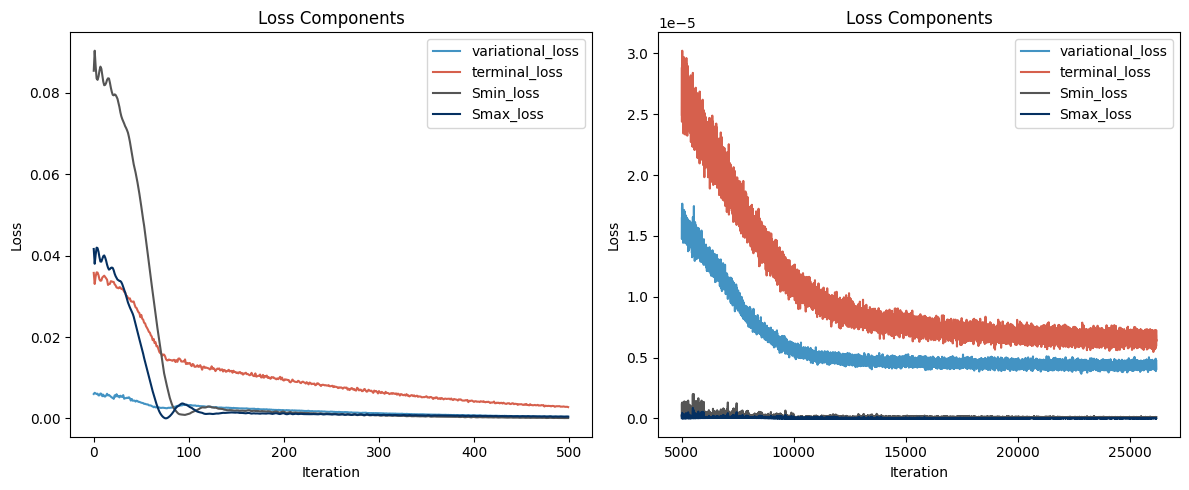

In [8]:
plt.figure(figsize=figsize2)

plt.subplot(1, 2, 1)
start_epoch = 0
end_epoch = 500
detailed = True

x = range(start_epoch, end_epoch)
for key in pinn.history:
    if (key == 'loss') ^ (detailed):
        plt.plot(x, pinn.history[key][start_epoch:end_epoch], label=key)

plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title("Loss Components")
plt.legend()

plt.subplot(1, 2, 2)
start_epoch = 5000
end_epoch = len(pinn.history['loss'])
detailed = True
x = range(start_epoch, end_epoch)
for key in pinn.history:
    if (key == 'loss') ^ (detailed):
        plt.plot(x, pinn.history[key][start_epoch:end_epoch], label=key)

plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title("Loss Components")
plt.legend()

plt.tight_layout()

plt.savefig(f"../../plots/black_scholes/bs_1d_train_loss.png")
plt.show()

In [5]:
atm_prices = [pinn.atm_price[i] for i in range(len(pinn.atm_price))]

In [6]:
# True price benchmark
from black_scholes.tree.tree import BinomialTree
bt = BinomialTree(K, r, sigma, T, n_steps=1000)
true_atm_price = bt.predict(0, K)
print(true_atm_price)

[0.08336577]


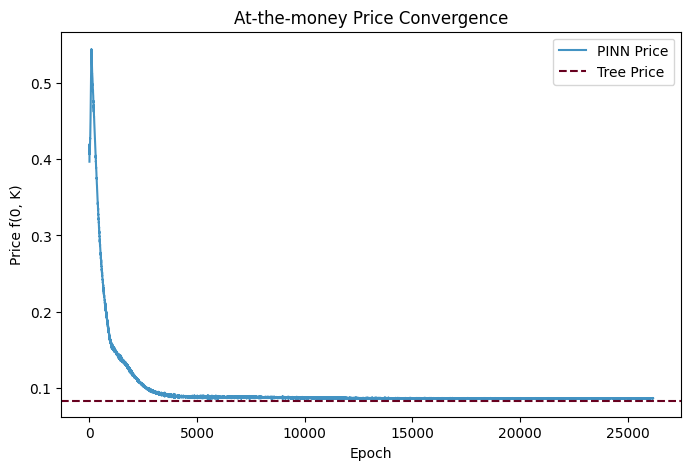

In [9]:
plt.figure(figsize=figsize1)
plt.plot(atm_prices, label='PINN Price')
plt.axhline(true_atm_price, color=CRIMSON, linestyle='--', label='Tree Price')
plt.xlabel('Epoch')
plt.ylabel('Price f(0, K)')
plt.title("At-the-money Price Convergence")
plt.legend()
plt.savefig(f"../../plots/black_scholes/bs_1d_train_atm_price.png")
plt.show()